In [3]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import PIL
from PIL import Image

## Below is the X-Ray image of a person suffering from Pneumonia.

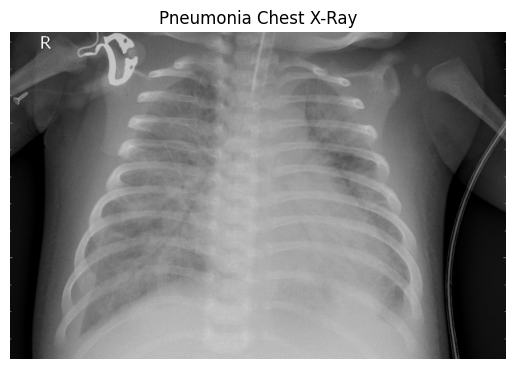

In [ ]:
img = Image.open(os.path.join(r"C:/Medical-Image-Classification/archive/train/PNEUMONIA", os.listdir(r"C:/Medical-Image-Classification/archive/train/PNEUMONIA")[0]))
plt.imshow(img, cmap="gray")
plt.title("Pneumonia Chest X-Ray")
plt.axis("off")
plt.show()

## Below is the X-Ray Image Of Normal Lungs

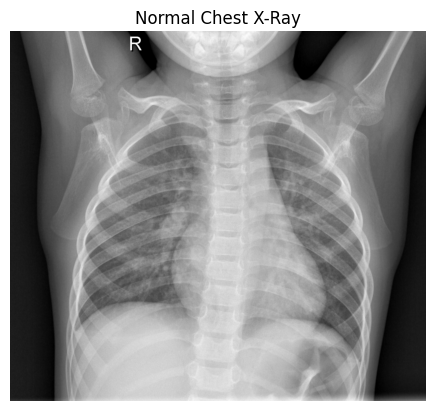

In [21]:
img = Image.open(os.path.join(r"C:/Medical-Image-Classification/archive/train/NORMAL", os.listdir(r"C:/Medical-Image-Classification/archive/train/NORMAL")[0]))
plt.imshow(img, cmap="gray")
plt.title("Normal Chest X-Ray")
plt.axis("off")
plt.show()

# Loading The Training and Validation Images From the Dataset

In [4]:
def loadImages(path,urls,target):
    images=[]
    labels=[]
    for i in range(len(urls)):
        img_path = path+"/"+urls[i]
        img = cv2.imread(img_path)
        img = img/255.0
        img = cv2.resize(img, (100,100))
        images.append(img)
        labels.append(target)
    images = np.asanyarray(images)
    return images,labels

In [5]:
# Loading Pneumonia training images
PneumoniaPath = r"C:/Medical-Image-Classification/archive/train/PNEUMONIA"
PneumoniaUrl = os.listdir(PneumoniaPath)
PneumoniaImages, PneumoniaTargets = loadImages(PneumoniaPath, PneumoniaUrl, 1)

In [6]:
# Loading Normal training images
normalPath = r"C:/Medical-Image-Classification/archive/train/NORMAL"
normalUrl = os.listdir(normalPath)
normalImages, normalTargets = loadImages(normalPath, normalUrl, 0)

In [7]:
PneumoniaImages = np.asarray(PneumoniaImages)
normalImages = np.asarray(normalImages)
PneumoniaImages.shape

(3875, 100, 100, 3)

In [8]:
normalImages.shape

(1341, 100, 100, 3)

In [9]:
# Concatenating Both Normal Images and Covid19 Images
Mixed_Datasets = np.r_[PneumoniaImages,normalImages]
Mixed_Datasets.shape

(5216, 100, 100, 3)

In [10]:
Targets = np.r_[PneumoniaTargets, normalTargets]

# Developing a Convolutional Neural Network for the classification task

In [11]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [12]:
x_train, x_test, y_train, y_test = train_test_split(Mixed_Datasets,Targets,test_size=0.25)

In [13]:
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),input_shape=(100,100,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Conv2D(256,(3,3),activation='relu'), 
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
    
])

c:\Medical-Image-Classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,437,505 (5.48 MB)

 Trainable params: 1,437,505 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

## Using the Adam optmizer

In [15]:
model.compile(optimizer = 'adam', loss=tf.keras.losses.BinaryCrossentropy(),metrics=['accuracy'])
#model.compile(optimizer=tf.keras.optimizers.Adam(lr=0.001),loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=10,epochs=10,validation_data=(x_test, y_test))

Epoch 1/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.8392 - loss: 0.3689 - val_accuracy: 0.9394 - val_loss: 0.1641
Epoch 2/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9404 - loss: 0.1575 - val_accuracy: 0.8635 - val_loss: 0.3094
Epoch 3/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9525 - loss: 0.1127 - val_accuracy: 0.9525 - val_loss: 0.1199
Epoch 4/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9624 - loss: 0.1049 - val_accuracy: 0.9578 - val_loss: 0.0976
Epoch 5/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9660 - loss: 0.0877 - val_accuracy: 0.9594 - val_loss: 0.0925
Epoch 6/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9734 - loss: 0.0720 - val_accuracy: 0.9678 - val_loss: 0.0775
Epoch 7/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9732 - loss: 0.0742 - val_accuracy: 0.9563 - val_loss: 0.1149
Epoch 8/10
392/392 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9788 - loss: 0.0570 - 

# Plotting the training and validation accuracy with respect to the number of epochs

<Figure size 640x480 with 0 Axes>

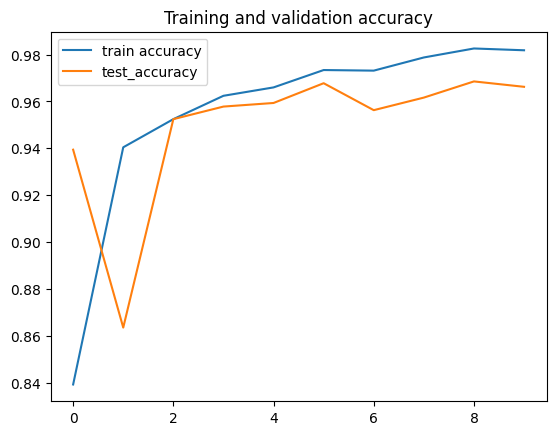

<Figure size 640x480 with 0 Axes>

In [16]:
plt.plot(model.history.history['accuracy'],label='train accuracy')
plt.plot(model.history.history['val_accuracy'],label='test_accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

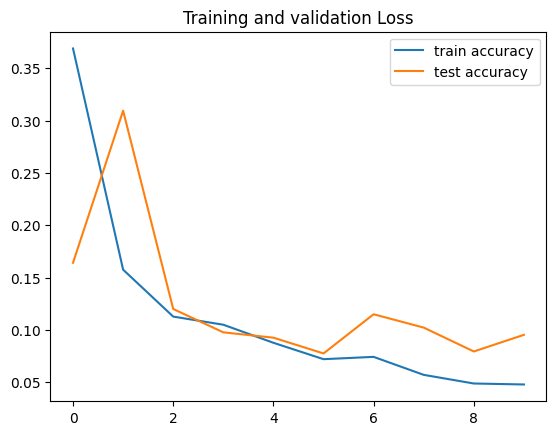

In [17]:
plt.plot(model.history.history['loss'],label='train accuracy')
plt.plot(model.history.history['val_loss'],label='test accuracy')
plt.title('Training and validation Loss')
plt.legend(loc=0)
plt.show()

In [18]:
print("The Training Accuracy:" ,model.history.history['accuracy'])
print("The Highest Training Accuracy: 0.9640787839889526")
print("\n")
print("The Validation Accuracy" ,model.history.history['val_accuracy'])
print("The Highest Validation Accuracy: 0.967024564743042")


The Training Accuracy: [0.8392126560211182, 0.9404397010803223, 0.9524539709091187, 0.9624233245849609, 0.9660020470619202, 0.9734151363372803, 0.9731594920158386, 0.9787832498550415, 0.9826176166534424, 0.9818507432937622]
The Highest Training Accuracy: 0.9640787839889526


The Validation Accuracy [0.9394171833992004, 0.8634969592094421, 0.9524539709091187, 0.9578220844268799, 0.9593558311462402, 0.9677914381027222, 0.9562883377075195, 0.9616564512252808, 0.9685583114624023, 0.9662576913833618]
The Highest Validation Accuracy: 0.967024564743042
